# Libraries and functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


def _extract_metric_at_epoch(eval_epochs, metric_values, epoch=None):
    eval_epochs = np.asarray(eval_epochs)
    metric_values = np.asarray(metric_values, dtype=float)

    if metric_values.size == 0:
        return np.nan

    if epoch is None:
        return float(metric_values[-1])

    matches = np.where(eval_epochs == epoch)[0]
    if len(matches) == 0:
        return np.nan
    return float(metric_values[matches[-1]])


def available_common_epochs(data):
    epochs_list = []
    for arr in data["eval_epochs"]:
        arr = np.asarray(arr, dtype=int)
        if arr.size > 0:
            epochs_list.append(set(arr.tolist()))

    if not epochs_list:
        return []

    common = set.intersection(*epochs_list)
    return sorted(common)


def build_phase_diagram_arrays(
    npz_path,
    metric_key="test_loss_std_mse",
    epoch=None,
):
    data = np.load(npz_path, allow_pickle=True)

    lr = np.asarray(data["lr"], dtype=float)
    inv_sigma_w = np.asarray(data["inv_sigma_w"], dtype=float)

    lr_vals = np.sort(np.unique(lr))
    inv_sigma_vals = np.sort(np.unique(inv_sigma_w))

    # y-axis = lr, x-axis = inv_sigma_w
    phase_matrix = np.full((len(lr_vals), len(inv_sigma_vals)), np.nan, dtype=float)
    counts_matrix = np.zeros((len(lr_vals), len(inv_sigma_vals)), dtype=int)

    scalar_metric_keys = {
        "final_train_loss_std_mse",
        "final_test_loss_std_mse",
        "final_train_mae_years",
        "final_test_mae_years",
        "final_train_mse_years",
        "final_test_mse_years",
    }

    for i_lr, lr_val in enumerate(lr_vals):
        for j_inv, inv_val in enumerate(inv_sigma_vals):
            mask = (lr == lr_val) & (inv_sigma_w == inv_val)
            idxs = np.where(mask)[0]

            vals = []
            for idx in idxs:
                if metric_key in scalar_metric_keys:
                    v = float(data[metric_key][idx])
                else:
                    eval_epochs = data["eval_epochs"][idx]
                    metric_values = data[metric_key][idx]
                    v = _extract_metric_at_epoch(eval_epochs, metric_values, epoch=epoch)

                if np.isfinite(v):
                    vals.append(v)
                if v>100:
                    vals.append(100)

            if len(vals) > 0:
                phase_matrix[i_lr, j_inv] = float(np.mean(vals))
                counts_matrix[i_lr, j_inv] = len(vals)

    return inv_sigma_vals, lr_vals, phase_matrix, counts_matrix


def plot_phase_diagram_imshow(
    npz_path,
    metric_key="test_loss_std_mse",
    epoch=None,
    title=None,
    annotate=False,
    figsize=(6, 5),
):
    inv_sigma_vals, lr_vals, phase_matrix, counts_matrix = build_phase_diagram_arrays(
        npz_path=npz_path,
        metric_key=metric_key,
        epoch=epoch,
    )

    masked = np.ma.masked_invalid(phase_matrix)

    cmap = mpl.colormaps["viridis"].copy()
    cmap.set_bad(color="lightgray")

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(np.log(masked), origin="lower", aspect="auto", cmap=cmap)

    ax.set_xticks(np.arange(len(inv_sigma_vals)))
    ax.set_xticklabels([f"{x:g}" for x in inv_sigma_vals], rotation=45)
    ax.set_yticks(np.arange(len(lr_vals)))
    ax.set_yticklabels([f"{x:g}" for x in lr_vals])

    ax.set_xlabel(r"$1/\sigma_w$")
    ax.set_ylabel("learning rate")

    if title is None:
        if epoch is None:
            ax.set_title(f"{metric_key} (last available epoch, mean over seeds)")
        else:
            ax.set_title(f"{metric_key} (epoch={epoch}, mean over seeds)")
    else:
        ax.set_title(title)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(metric_key)

    if annotate:
        for i in range(phase_matrix.shape[0]):
            for j in range(phase_matrix.shape[1]):
                txt = "NaN" if np.isnan(phase_matrix[i, j]) else f"{phase_matrix[i, j]:.3g}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=8)

    plt.tight_layout()
    return fig, ax, inv_sigma_vals, lr_vals, phase_matrix, counts_matrix

# Experiment 2 - CNN

## With SGD

In [15]:
data = np.load("collected_results/exp2_v5.npz", allow_pickle=True)

print(data.files)
print(data["lr"])
print(data["inv_sigma_w"])
print(data["final_test_loss_std_mse"])

['run_id', 'run_dir', 'dataset_root', 'architecture_json', 'dataset_json', 'train_json', 'eval_epochs', 'train_loss_std_mse', 'test_loss_std_mse', 'train_mae_years', 'test_mae_years', 'train_mse_years', 'test_mse_years', 'seed', 'lr', 'inv_sigma_w', 'sigma2_w', 'batch_size', 'epochs', 'n_train', 'n_test', 'target_mean_years', 'target_std_years', 'final_train_loss_std_mse', 'final_test_loss_std_mse', 'final_train_mae_years', 'final_test_mae_years', 'final_train_mse_years', 'final_test_mse_years']
[0.002 0.008 0.032 0.128 0.512 0.002 0.008 0.032 0.128 0.512 0.002 0.008
 0.032 0.128 0.512 0.002 0.008 0.032 0.128 0.512 0.002 0.008 0.032 0.128
 0.512]
[  1.   1.   1.   1.   1.   4.   4.   4.   4.   4.  16.  16.  16.  16.
  16.  32.  32.  32.  32.  32. 128. 128. 128. 128. 128.]
[0.357231   0.25759648 0.24679308        nan        nan 0.96384122
 0.3414369  0.25290944 0.25392468 1.04207168 1.03199654 1.03199515
 1.03246922 1.03347595 1.04207168 1.03199653 1.03199518 1.03246922
 1.03347595 1.04

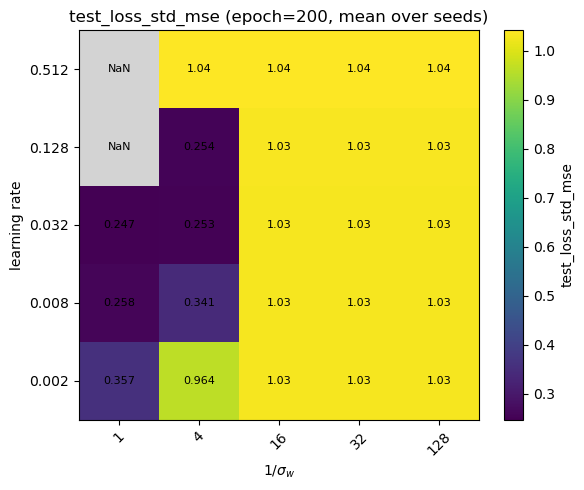

In [27]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_v5.npz",
    metric_key="test_loss_std_mse",
    epoch=200,
    annotate=True,
)
plt.show()

In [29]:
data = np.load("collected_results/exp2_v6.npz", allow_pickle=True)

print(data.files)
print(data["lr"])
print(data["inv_sigma_w"])
print(data["final_test_loss_std_mse"])

['run_id', 'run_dir', 'dataset_root', 'architecture_json', 'dataset_json', 'train_json', 'eval_epochs', 'train_loss_std_mse', 'test_loss_std_mse', 'train_mae_years', 'test_mae_years', 'train_mse_years', 'test_mse_years', 'seed', 'lr', 'inv_sigma_w', 'sigma2_w', 'batch_size', 'epochs', 'n_train', 'n_test', 'target_mean_years', 'target_std_years', 'final_train_loss_std_mse', 'final_test_loss_std_mse', 'final_train_mae_years', 'final_test_mae_years', 'final_train_mse_years', 'final_test_mse_years']
[0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128
 0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128
 0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128]
[ 0.5  0.5  0.5  0.5  0.5  0.5  1.   1.   1.   1.   1.   1.   2.   2.
  2.   2.   2.   2.   4.   4.   4.   4.   4.   4.   8.   8.   8.   8.
  8.   8.  16.  16.  16.  16.  16.  16. ]
[       nan        nan        nan        nan        nan        nan
 0.33420071 0.28555817 0.25305

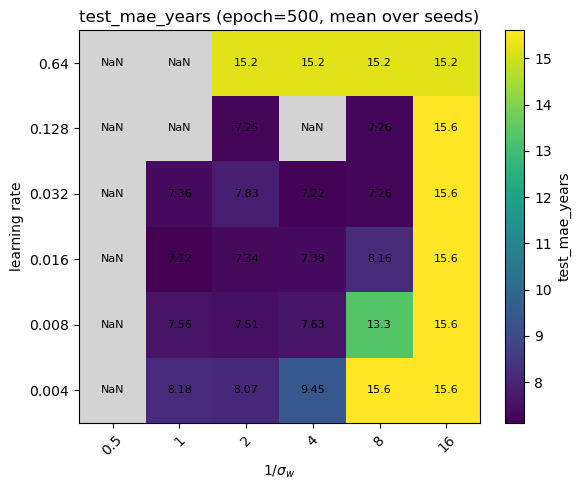

In [22]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_v6.npz",
    metric_key="test_mae_years",
    epoch=500,
    annotate=True,
)
plt.show()

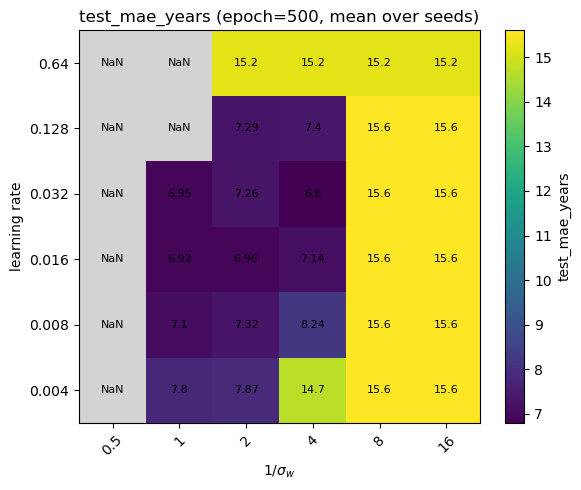

In [20]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_mlp_v1_sgd.npz",
    metric_key="test_mae_years",
    epoch=500,
    annotate=True,
)
plt.show()

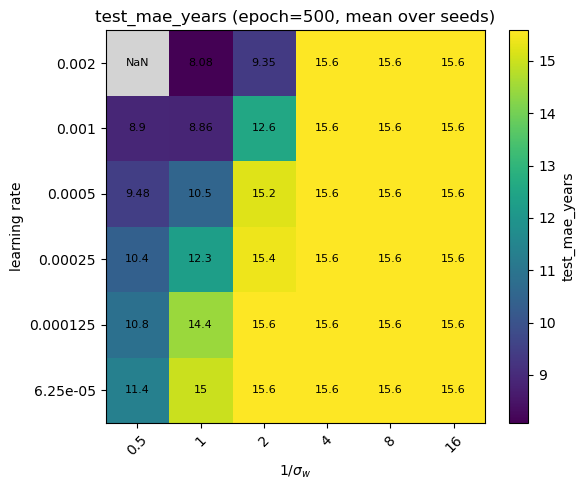

In [25]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_mlp_v5_sgd.npz",
    metric_key="test_mae_years",
    epoch=500,
    annotate=True,
)
plt.show()

## With AdaM

In [2]:
data = np.load("collected_results/exp2_v8.npz", allow_pickle=True)

print(data.files)
print(data["lr"])
print(data["inv_sigma_w"])
print(data["final_test_loss_std_mse"])

['run_id', 'run_dir', 'dataset_root', 'architecture_json', 'dataset_json', 'train_json', 'eval_epochs', 'train_loss_std_mse', 'test_loss_std_mse', 'train_mae_years', 'test_mae_years', 'train_mse_years', 'test_mse_years', 'seed', 'lr', 'inv_sigma_w', 'sigma2_w', 'batch_size', 'epochs', 'n_train', 'n_test', 'target_mean_years', 'target_std_years', 'final_train_loss_std_mse', 'final_test_loss_std_mse', 'final_train_mae_years', 'final_test_mae_years', 'final_train_mse_years', 'final_test_mse_years']
[0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128
 0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128
 0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128]
[ 0.5  0.5  0.5  0.5  0.5  0.5  1.   1.   1.   1.   1.   1.   2.   2.
  2.   2.   2.   2.   4.   4.   4.   4.   4.   4.   8.   8.   8.   8.
  8.   8.  16.  16.  16.  16.  16.  16. ]
[2.81379470e-01 3.51943527e-01 1.03213011e+00 1.03206822e+00
 1.03781024e+00 1.03736843e+00 4.078

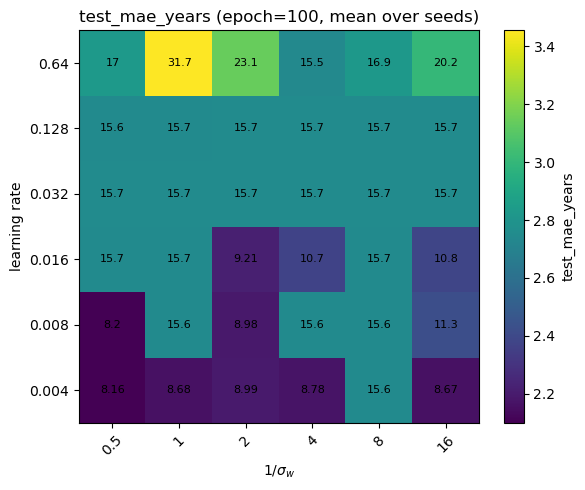

In [13]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_v8.npz",
    metric_key="test_mae_years",
    epoch= 100,
    annotate=True,
)
plt.show()

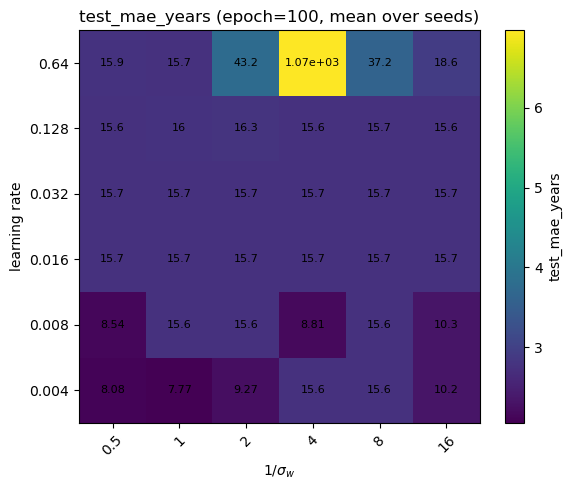

In [15]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_mlp_v4_adam.npz",
    metric_key="test_mae_years",
    epoch= 100,
    annotate=True,
)
plt.show()

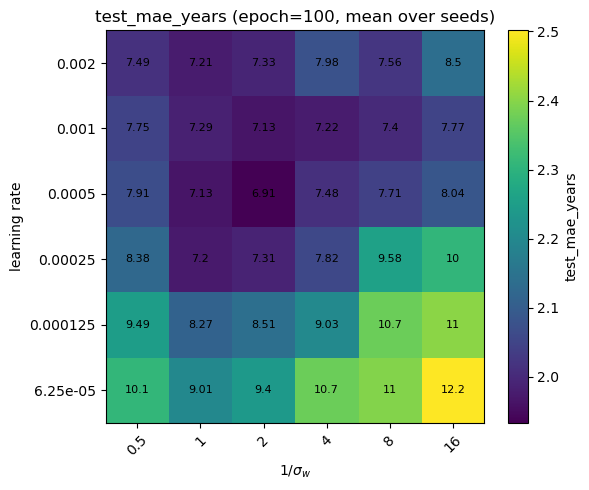

In [16]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_mlp_v5_adam.npz",
    metric_key="test_mae_years",
    epoch= 100,
    annotate=True,
)
plt.show()

# Experiment 2 - DNN

## SGD - 1 hidden

### Relu

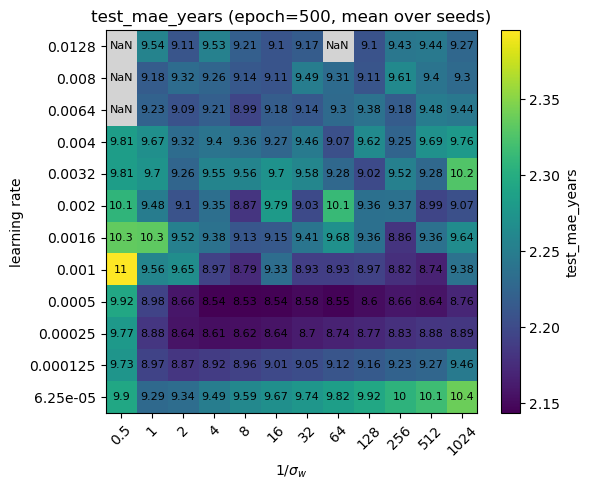

In [4]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_v1_sgd_relu.npz",
    metric_key="test_mae_years",
    epoch= 500,
    annotate=True,
)
plt.show()

### tanh

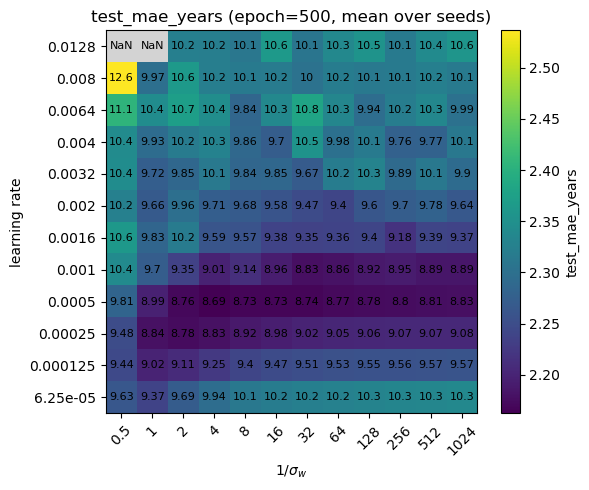

In [3]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_v1_sgd_tanh.npz",
    metric_key="test_mae_years",
    epoch= 500,
    annotate=True,
)
plt.show()

## SGD - three hidden

### relu

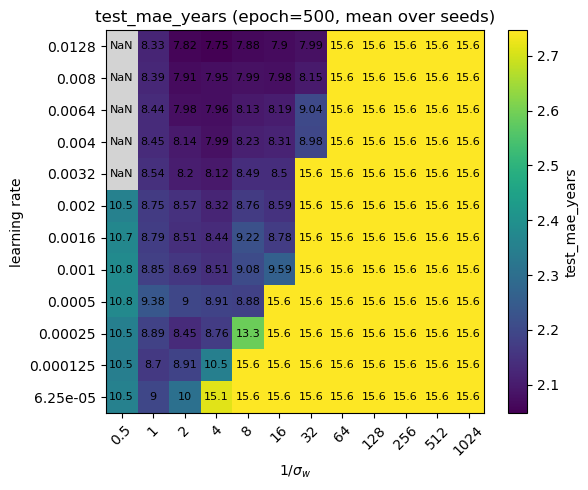

In [4]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_relu.npz",
    metric_key="test_mae_years",
    epoch= 500,
    annotate=True,
)
plt.show()

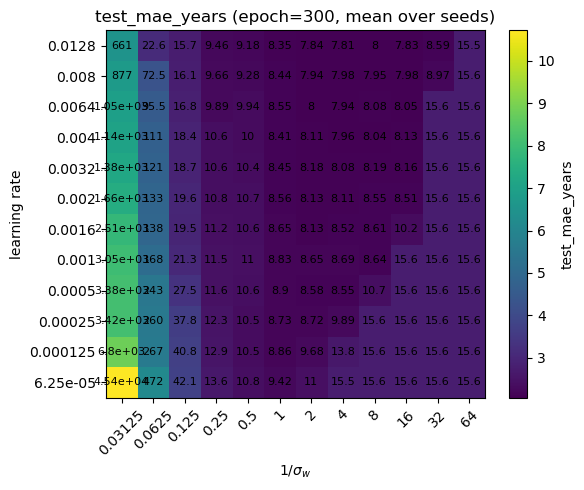

In [2]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_relu_v3.npz",
    metric_key="test_mae_years",
    epoch= 300,
    annotate=True,
)
plt.show()

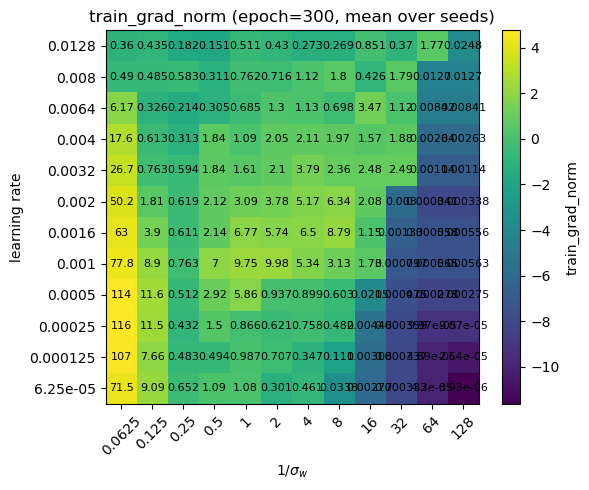

In [3]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_v3.npz",
    metric_key="train_grad_norm",
    epoch= 300,
    annotate=True,
)
plt.show()

### tanh

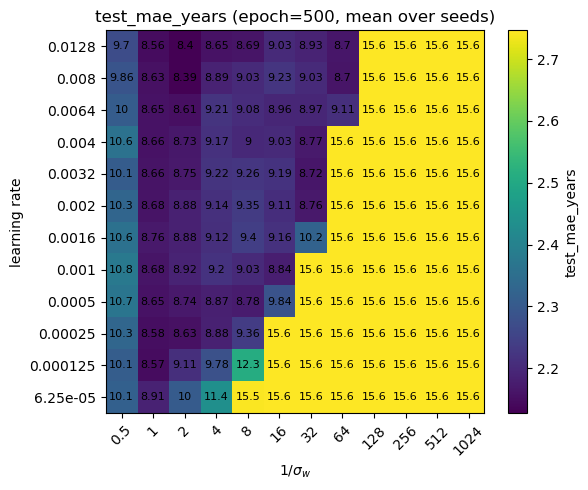

In [4]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh.npz",
    metric_key="test_mae_years",
    epoch= 500,
    annotate=True,
)
plt.show()

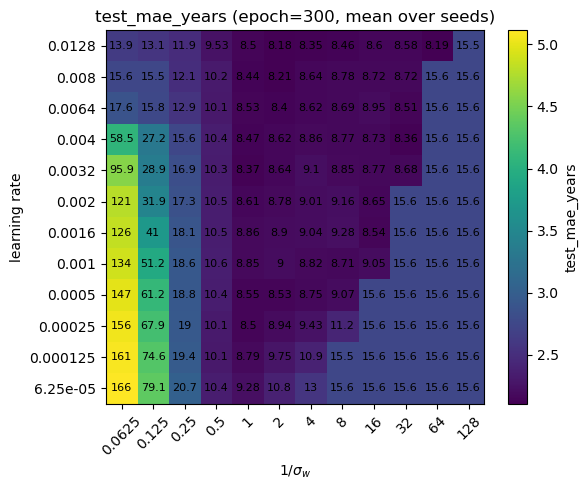

In [3]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_v3.npz",
    metric_key="test_mae_years",
    epoch= 300,
    annotate=True,
)
plt.show()

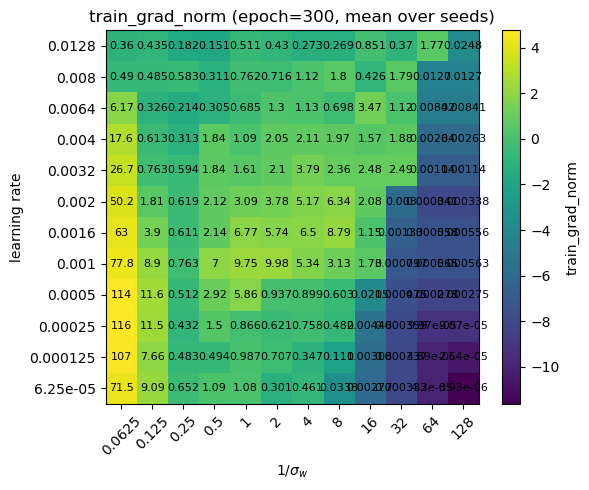

In [6]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_v3.npz",
    metric_key="train_grad_norm",
    epoch= 300,
    annotate=True,
)
plt.show()